# Land Cover Change Detection: Annual NDVI Composites

This notebook produces one cloud-free median NDVI composite per year (2018–2025) for the GSMNP AOI. Each composite is written as a 2-band GeoTIFF: band 1 is median NDVI (float32), band 2 is the per-pixel count of valid observations used in the median (float32).

**Inputs:** `data/gsmnp_aoi.gpkg`, `data/gsmnp_aoi_4326.geojson` (from notebook 01)  
**Outputs:** `data/composites/ndvi_2018.tif` through `ndvi_2025.tif`  
**Expected runtime:** 2–4 hours total (15–30 min/year, network-dependent)

Run this notebook, let it finish, and come back. The loop prints progress per year so you can monitor it.

In [3]:
import gc
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import rasterio.transform
import stackstac
import xarray as xr
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("data")
COMPOSITES_DIR = DATA_DIR / "composites"
COMPOSITES_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2018, 2026))

## Dask LocalCluster

stackstac uses dask to lazily represent the image stack — no data is fetched until `.compute()` is called. A `LocalCluster` with 2 workers and 4 GB memory limit per worker keeps us from swamping the machine while still parallelizing COG range requests across scenes.

The dashboard link below lets you watch task progress in a browser tab while the loop runs.

In [4]:
cluster = LocalCluster(n_workers=2, threads_per_worker=2, memory_limit="4GB")
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")
print(f"Workers:        {len(client.scheduler_info()['workers'])}")

Dask dashboard: http://127.0.0.1:8787/status
Workers:        2


## AOI and STAC Connection

In [5]:
aoi_5070 = gpd.read_file(DATA_DIR / "gsmnp_aoi.gpkg")
aoi_4326 = gpd.read_file(DATA_DIR / "gsmnp_aoi_4326.geojson")
aoi_geom = aoi_4326.geometry.iloc[0]
bbox_4326 = aoi_4326.total_bounds.tolist()  # [minx, miny, maxx, maxy]

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print(f"AOI area:  {aoi_5070.area.sum() / 1e6:.0f} km²")
print(f"STAC bbox: {[round(v, 4) for v in bbox_4326]}")

AOI area:  5103 km²
STAC bbox: [-84.1252, 35.3397, -82.8867, 35.9307]


## Retry Helpers

Planetary Computer is a remote service — network failures happen. Rather than letting them crash the multi-hour loop, we wrap the two call sites that talk to the outside world:

- **`stac_search_with_retry`** wraps `pystac_client` item pagination. On failure it waits, re-opens a fresh catalog connection (in case the session is stale), and retries.
- **`dask_compute_with_retry`** wraps the dask compute + gather step. The inner `retries=5` on `client.compute()` handles per-task COG read failures at the scheduler level. The outer retry loop handles broader failures by restarting the dask workers and resubmitting.

In [6]:
PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

# GDAL HTTP retry config — passed into each dask worker via stackstac's gdal_env.
# GDAL handles retries at the range-request level, before failures ever reach dask.
GDAL_ENV = {
    "GDAL_HTTP_MAX_RETRY": "5",       # retry each HTTP range request up to 5 times
    "GDAL_HTTP_RETRY_DELAY": "3",     # wait 3 seconds between GDAL-level retries
    "GDAL_HTTP_TIMEOUT": "60",        # fail a single request after 60s (vs hanging)
}


def stac_search_with_retry(catalog, retries=5, backoff=10, **search_kwargs):
    """
    Search Planetary Computer STAC and collect all items, with retry on network failure.
    Re-opens the catalog connection on each retry since the HTTP session may be stale.
    Returns (items, catalog) — use the returned catalog for all subsequent calls so any
    reconnected instance propagates through the loop.
    """
    for attempt in range(retries):
        try:
            search = catalog.search(**search_kwargs)
            items = list(search.items())
            return items, catalog
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"       STAC search failed (attempt {attempt + 1}/{retries}): {type(e).__name__}: {e}")
            print(f"       Reconnecting in {wait}s...")
            time.sleep(wait)
            catalog = pystac_client.Client.open(
                PC_STAC_URL,
                modifier=planetary_computer.sign_inplace,
            )


def dask_compute_with_retry(client, *lazy_arrays, retries=3, backoff=30):
    """
    Compute one or more lazy dask/xarray objects with retry on failure.
    GDAL_ENV handles individual HTTP range-request failures at the GDAL level.
    This outer wrapper catches cases where the whole computation fails (e.g. a worker
    running out of memory), waits, and resubmits without restarting workers — worker
    restart resets GDAL connection state and causes 403s on subsequent Azure requests.
    Returns a tuple of computed results in the same order as the inputs.
    """
    for attempt in range(retries):
        try:
            futures = client.compute(list(lazy_arrays))
            results = client.gather(futures)
            return tuple(results)
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"       Compute failed (attempt {attempt + 1}/{retries}): {type(e).__name__}")
            print(f"       Retrying in {wait}s (no worker restart — preserves GDAL state)...")
            time.sleep(wait)

## Processing Baseline Harmonization

Sentinel-2 processing baseline 04.00 (introduced in 2022) added a +1000 DN offset to all reflectance bands to prevent negative values in high-altitude scenes. Pre-04.00 data (2018–2021) has no such offset. Comparing raw DN across the full 2018–2025 record without correction would produce a spurious NDVI step change around 2021–2022 — stable forest would appear to shift.

The fix: subtract 1000 from B04 and B08 for any scene with baseline ≥ 04.00, then clip to a minimum of 0. This brings all scenes onto pre-04.00 radiometry before computing NDVI. The SCL band is a classification layer, not a reflectance measurement, so it is never adjusted.

stackstac stores `s2:processing_baseline` as a per-scene coordinate on the time dimension, so we can identify which scenes need correction without any external lookup.

## Annual Compositing Loop

Per year:
1. Query Planetary Computer for Jul 1 – Aug 31, cloud cover < 20%
2. Stack with stackstac (lazy): bands B04, B08, SCL; EPSG:5070; 10 m; 2048-px chunks
3. Harmonize baseline offsets per scene
4. Apply SCL cloud mask — set B04/B08 to NaN where SCL ∉ {4, 5, 6}
5. Compute NDVI = (B08 − B04) / (B08 + B04)
6. Median across the time dimension; count of valid (non-NaN) observations per pixel
7. Trigger dask computation, write 2-band GeoTIFF, release memory

In [7]:
VALID_SCL = {4, 5, 6}  # vegetation, bare soil, water

for year in YEARS:
    t0 = time.time()
    out_path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    if out_path.exists():
        print(f"{year}: already exists, skipping")
        continue

    # --- 1. STAC search (with retry + reconnect on network failure) ---
    items, catalog = stac_search_with_retry(
        catalog,
        collections=["sentinel-2-l2a"],
        bbox=bbox_4326,
        datetime=f"{year}-07-01/{year}-08-31",
        query={"eo:cloud_cover": {"lt": 20}},
    )
    print(f"\n{year}: {len(items)} scenes found")

    # --- 2. Stack (lazy) ---
    # gdal_env: GDAL retries transient HTTP failures before surfacing them to dask.
    # errors_as_nodata: if an asset is permanently unreadable, treat pixels as NaN rather
    # than crashing — a median across 12-28 scenes degrades gracefully with one bad asset.
    stack = stackstac.stack(
        items,
        assets=["B04", "B08", "SCL"],
        epsg=5070,
        resolution=10,
        chunksize=1024,
        bounds_latlon=aoi_geom.bounds,
        gdal_env=stackstac.DEFAULT_GDAL_ENV.updated(always=GDAL_ENV),
        errors_as_nodata=(Exception(".*"),),
    )
    # stack dims: (time, band, y, x)

    # --- 3. Baseline harmonization ---
    # s2:processing_baseline collapses to a scalar (0-d) when all scenes share the same
    # baseline, and is 1-d (time,) when mixed. Handle both.
    bl_coord = stack.coords["s2:processing_baseline"]
    if bl_coord.ndim == 0:
        needs_offset = np.full(stack.sizes["time"], str(bl_coord.values) >= "04.00")
    else:
        needs_offset = np.array([str(b) >= "04.00" for b in bl_coord.values])

    b04 = stack.sel(band="B04")
    b08 = stack.sel(band="B08")
    scl = stack.sel(band="SCL")

    # 1-d (time,) DataArray — xarray broadcasts over y,x automatically
    offset_da = xr.DataArray(
        1000.0 * needs_offset,
        dims=["time"],
        coords={"time": b04.time},
    )
    b04 = (b04 - offset_da).clip(min=0)
    b08 = (b08 - offset_da).clip(min=0)

    print(f"       harmonized {int(needs_offset.sum())}/{len(items)} scenes (baseline >= 04.00)")

    # --- 4. SCL cloud mask ---
    valid_mask = sum(scl == v for v in VALID_SCL).astype(bool)
    b04 = b04.where(valid_mask)
    b08 = b08.where(valid_mask)

    # --- 5. NDVI ---
    ndvi = (b08 - b04) / (b08 + b04)

    # --- 6. Median + valid count (lazy) ---
    ndvi_median = ndvi.median(dim="time")
    valid_count = ndvi.notnull().sum(dim="time").astype("float32")

    # --- 7. Compute (outer retry for whole-computation failures; GDAL handles per-request) ---
    print(f"       computing...")
    ndvi_result, count_result = dask_compute_with_retry(client, ndvi_median, valid_count)
    ndvi_arr = ndvi_result.values.astype("float32")
    count_arr = count_result.values.astype("float32")
    del ndvi_result, count_result

    # stackstac pixel centers → derive rasterio transform from top-left origin
    res = 10
    x0 = float(ndvi_median.x[0]) - res / 2
    y0 = float(ndvi_median.y[0]) + res / 2
    transform = rasterio.transform.from_origin(x0, y0, res, res)

    # --- 8. Write GeoTIFF ---
    meta = {
        "driver": "GTiff",
        "dtype": "float32",
        "count": 2,
        "crs": "EPSG:5070",
        "transform": transform,
        "width": ndvi_arr.shape[1],
        "height": ndvi_arr.shape[0],
        "nodata": float("nan"),
        "compress": "lzw",
    }
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(ndvi_arr, 1)
        dst.update_tags(1, description="Median NDVI (Jul-Aug)")
        dst.write(count_arr, 2)
        dst.update_tags(2, description="Valid observation count")

    elapsed = time.time() - t0
    mean_ndvi = float(np.nanmean(ndvi_arr))
    pct_low = float(np.mean(count_arr[~np.isnan(ndvi_arr)] < 3) * 100)
    size_mb = out_path.stat().st_size / 1e6
    print(f"       done in {elapsed/60:.1f} min | mean NDVI {mean_ndvi:.3f} | "
          f"<3 obs: {pct_low:.1f}% | {size_mb:.0f} MB → {out_path.name}")

    # --- 9. Release memory ---
    del stack, b04, b08, scl, ndvi, ndvi_median, valid_count, ndvi_arr, count_arr
    client.run(gc.collect)
    gc.collect()

print("\nAll years complete.")

2018: already exists, skipping
2019: already exists, skipping
2020: already exists, skipping
2021: already exists, skipping
2022: already exists, skipping
2023: already exists, skipping
2024: already exists, skipping
2025: already exists, skipping

All years complete.


## Quick-Look Grid

Eight panels, one per year. Look for:
- **Tile seams:** any visible straight-line discontinuities where MGRS tiles meet. If present, the multi-tile median didn't blend properly.
- **NaN holes:** black patches in the interior of the AOI. A few at the edges are expected (raster bounds vs. irregular AOI shape); large interior holes mean too few valid observations.
- **NDVI range:** green values should dominate. Dense forest reads 0.7–0.9. Anything near zero or negative in the interior is a cloud-mask failure or bad scene.
- **Year-to-year consistency:** no sudden color shift between adjacent years, especially 2021→2022 (the baseline transition).

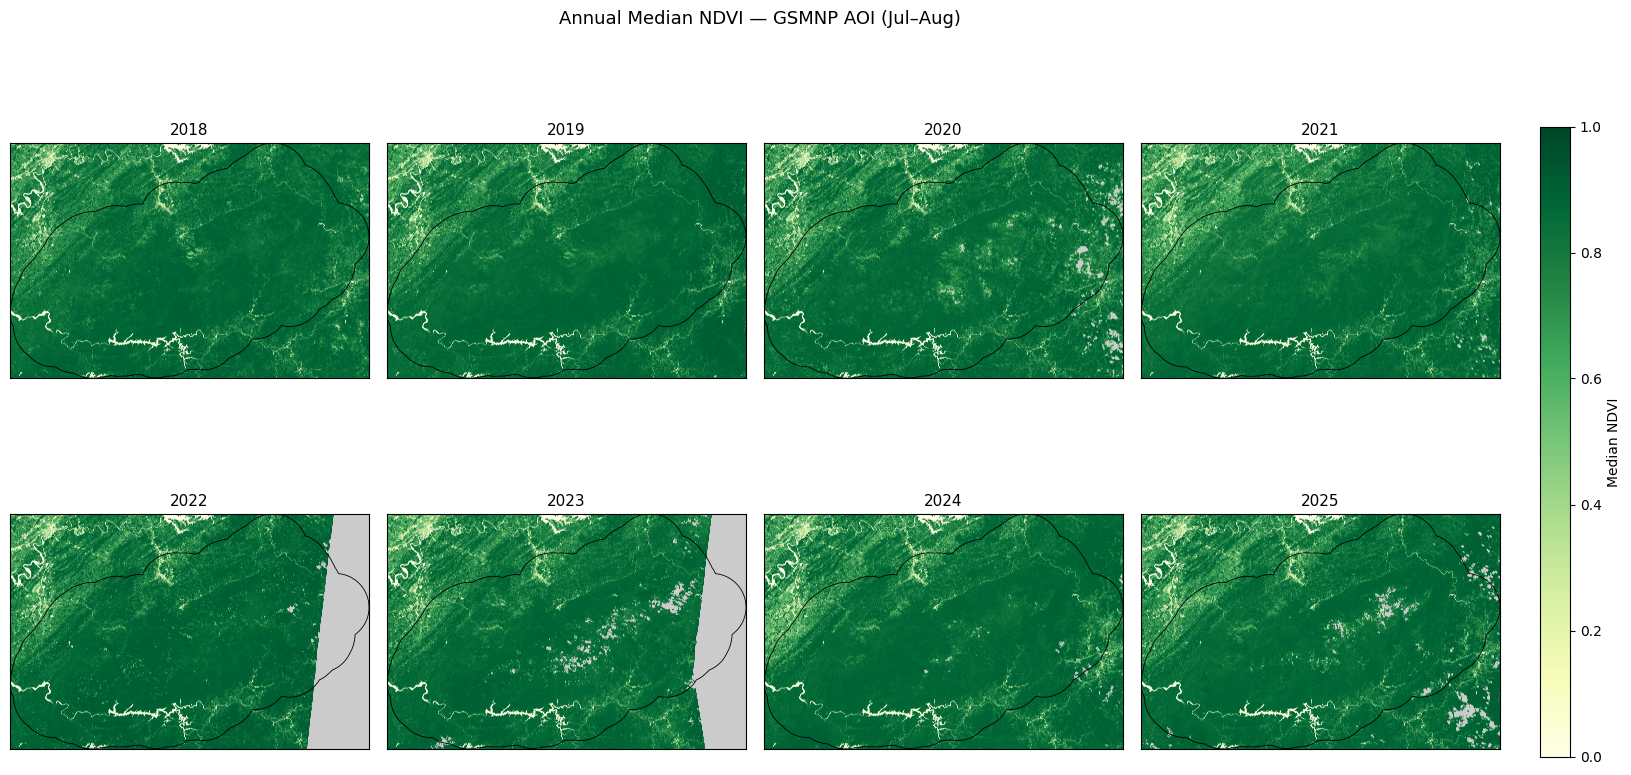

In [8]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad(color="#cccccc")  # NaN pixels → grey, distinct from vegetation

xmin, ymin, xmax, ymax = aoi_5070.total_bounds  # consistent axes limits for all panels

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, year in zip(axes, YEARS):
    path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    with rasterio.open(path) as src:
        ndvi = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    ax.set_facecolor("#cccccc")  # areas outside raster extent match NaN color
    im = ax.imshow(ndvi, cmap=cmap, vmin=0, vmax=1, extent=extent, origin="upper")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(str(year), fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.subplots_adjust(right=0.87, wspace=0.05, hspace=0.15)
cbar_ax = fig.add_axes([0.89, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Median NDVI")
plt.suptitle("Annual Median NDVI — GSMNP AOI (Jul–Aug)", fontsize=13)
plt.show()

## Per-Year Statistics

Expected values for a healthy composite over dense temperate forest:
- Mean NDVI: 0.70–0.90
- Pixels with < 3 valid observations: < 10% of non-NaN area

The `<3 obs %` column is the key quality indicator. Areas flagged here will be unreliable in the change detection step. Persistent cloud shadow on north-facing slopes is the most likely cause in GSMNP.

In [9]:
rows = []
for year in YEARS:
    path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    with rasterio.open(path) as src:
        ndvi = src.read(1).astype("float32")
        count = src.read(2).astype("float32")

    valid = ~np.isnan(ndvi)
    rows.append({
        "year": year,
        "min": f"{np.nanmin(ndvi):.3f}",
        "max": f"{np.nanmax(ndvi):.3f}",
        "mean": f"{np.nanmean(ndvi):.3f}",
        "std": f"{np.nanstd(ndvi):.3f}",
        "<3 obs %": f"{np.mean(count[valid] < 3) * 100:.1f}%",
        "NaN %": f"{np.mean(~valid) * 100:.1f}%",
        "size MB": f"{path.stat().st_size / 1e6:.0f}",
    })

stats = pd.DataFrame(rows).set_index("year")
print(stats.to_string())

         min    max   mean    std <3 obs %  NaN % size MB
year                                                     
2018  -0.999  0.989  0.808  0.162     3.9%   0.3%     451
2019  -0.999  0.999  0.811  0.170    15.3%   0.3%     455
2020  -0.987  1.000  0.789  0.183    17.3%   1.6%     457
2021  -0.999  1.000  0.790  0.167    15.0%   0.5%     454
2022  -1.000  1.000  0.813  0.194    11.6%  17.0%     375
2023  -0.794  1.000  0.795  0.181     4.5%  16.7%     383
2024  -1.000  0.998  0.800  0.179    10.9%   0.5%     446
2025  -1.000  1.000  0.803  0.184    18.8%   2.0%     444


## Before Proceeding to Notebook 03

Verify:
- All 8 TIFFs exist in `data/composites/`
- Mean NDVI is 0.70–0.90 for all years
- `<3 obs %` is below 10% for all years
- No visible tile seams in the quick-look grid
- No step change in NDVI between 2021 and 2022 in the grid (confirms baseline harmonization worked)

If 2022 looks anomalously low (only 12 scenes, late start July 23), that's expected — it still has enough coverage for a reliable composite. If any year shows >20% low-observation pixels, it's worth widening the date range to June–August for that year and rerunning.

When the stats look reasonable, move on to `03_lccd_change_detection.ipynb`.